# Sanity Check - Step 01: Inspect and Rename (BioSemi64 → 10-20)

Überprüft:
- Kanalumlabeling von BioSemi64 zu Standard 10-20
- Montage korrekt gesetzt
- Vorher-Nachher Vergleich der Kanal-Koordinaten

In [1]:
import sys
import mne
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent / 'eeg_pipeline'))
import config

print("Setup erfolgreich")

Setup erfolgreich


## 1. VORHER: Original Raw Daten (Step 00 Output)

In [2]:
subject_id = config.SUBJECTS[0]

# Step 00 Output laden
p1_path_before = config.OUTPUT_DIR / f"sub-{subject_id}_P1_raw.fif"
p2_path_before = config.OUTPUT_DIR / f"sub-{subject_id}_P2_raw.fif"

raw_p1_before = mne.io.read_raw_fif(str(p1_path_before), preload=False)
raw_p2_before = mne.io.read_raw_fif(str(p2_path_before), preload=False)

print(f"\n=== VORHER (Step 00 Output) ===\n")

# EEG Kanäle identifizieren
eeg_p1_before = raw_p1_before.copy().pick('eeg')
eeg_p2_before = raw_p2_before.copy().pick('eeg')

print(f"Person 1 - EEG Kanäle:")
print(f"  {eeg_p1_before.ch_names[:10]}")
print(f"  ... (insgesamt {len(eeg_p1_before.ch_names)} Kanäle)")

print(f"\nPerson 2 - EEG Kanäle:")
print(f"  {eeg_p2_before.ch_names[:10]}")
print(f"  ... (insgesamt {len(eeg_p2_before.ch_names)} Kanäle)")

# Koordinaten prüfen
print(f"\nMonage (VORHER - sollte None sein): {raw_p1_before.get_montage()}")


Opening raw data file c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P1_raw.fif...
Isotrak not found
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.
Opening raw data file c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P2_raw.fif...
Isotrak not found
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.

=== VORHER (Step 00 Output) ===

Person 1 - EEG Kanäle:
  ['1-A1', '1-A2', '1-A3', '1-A4', '1-A5', '1-A6', '1-A7', '1-A8', '1-A9', '1-A10']
  ... (insgesamt 64 Kanäle)

Person 2 - EEG Kanäle:
  ['2-A1', '2-A2', '2-A3', '2-A4', '2-A5', '2-A6', '2-A7', '2-A8', '2-A9', '2-A10']
  ... (insgesamt 64 Kanäle)

Monage (VORHER - sollte None sein): None


## 2. NACHHER: Renamed Raw Daten (Step 01 Output)

In [3]:
# Step 01 Output laden
p1_path_after = config.OUTPUT_DIR / f"sub-{subject_id}_P1_renamed_raw.fif"
p2_path_after = config.OUTPUT_DIR / f"sub-{subject_id}_P2_renamed_raw.fif"

raw_p1_after = mne.io.read_raw_fif(str(p1_path_after), preload=False)
raw_p2_after = mne.io.read_raw_fif(str(p2_path_after), preload=False)

print(f"\n=== NACHHER (Step 01 Output) ===\n")

# EEG Kanäle identifizieren
eeg_p1_after = raw_p1_after.copy().pick('eeg')
eeg_p2_after = raw_p2_after.copy().pick('eeg')

print(f"Person 1 - EEG Kanäle:")
print(f"  {eeg_p1_after.ch_names[:10]}")
print(f"  ... (insgesamt {len(eeg_p1_after.ch_names)} Kanäle)")

print(f"\nPerson 2 - EEG Kanäle:")
print(f"  {eeg_p2_after.ch_names[:10]}")
print(f"  ... (insgesamt {len(eeg_p2_after.ch_names)} Kanäle)")

# Montage prüfen
montage_after = raw_p1_after.get_montage()
print(f"\nMontage (NACHHER): {montage_after}")
if montage_after and hasattr(montage_after, 'kind'):
    print(f"Montage Kind: {montage_after.kind}")
else:
    print(f"Montage Kind: None or not available")


Opening raw data file c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P1_renamed_raw.fif...
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.
Opening raw data file c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P2_renamed_raw.fif...
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.

=== NACHHER (Step 01 Output) ===

Person 1 - EEG Kanäle:
  ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3']
  ... (insgesamt 64 Kanäle)

Person 2 - EEG Kanäle:
  ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3']
  ... (insgesamt 64 Kanäle)

Montage (NACHHER): <DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 64 channels>
Montage Kind: None or not available


## 3. Kanal-Mapping Vergleich

In [4]:
print(f"\n=== KANAL-MAPPING VERGLEICH ===\n")

# Erstelle Mapping Tabelle
print("Person 1 - Kanalumlabeling (Vorher → Nachher):")
print(f"{'Vorher':<10} → {'Nachher':<10}")
print("-" * 25)

for before, after in zip(eeg_p1_before.ch_names[:32], eeg_p1_after.ch_names[:32]):
    print(f"{before:<10} → {after:<10}")

print(f"\nPerson 2 - Kanalumlabeling (Vorher → Nachher):")
print(f"{'Vorher':<10} → {'Nachher':<10}")
print("-" * 25)

for before, after in zip(eeg_p2_before.ch_names[:32], eeg_p2_after.ch_names[:32]):
    print(f"{before:<10} → {after:<10}")



=== KANAL-MAPPING VERGLEICH ===

Person 1 - Kanalumlabeling (Vorher → Nachher):
Vorher     → Nachher   
-------------------------
1-A1       → Fp1       
1-A2       → AF7       
1-A3       → AF3       
1-A4       → F1        
1-A5       → F3        
1-A6       → F5        
1-A7       → F7        
1-A8       → FT7       
1-A9       → FC5       
1-A10      → FC3       
1-A11      → FC1       
1-A12      → C1        
1-A13      → C3        
1-A14      → C5        
1-A15      → T7        
1-A16      → TP7       
1-A17      → CP5       
1-A18      → CP3       
1-A19      → CP1       
1-A20      → P1        
1-A21      → P3        
1-A22      → P5        
1-A23      → P7        
1-A24      → P9        
1-A25      → PO7       
1-A26      → PO3       
1-A27      → O1        
1-A28      → Iz        
1-A29      → Oz        
1-A30      → POz       
1-A31      → Pz        
1-A32      → CPz       

Person 2 - Kanalumlabeling (Vorher → Nachher):
Vorher     → Nachher   
-------------------------
2-A

## 4. Kanal-Koordinaten Vergleich

In [5]:
# Hole Koordinaten
montage_after = raw_p1_after.get_montage()

if montage_after:
    print(f"\n=== KANAL-KOORDINATEN ===\n")
    print(f"Person 1 - 10-20 Koordinaten:")
    print(f"{'Kanal':<10} {'X':<10} {'Y':<10} {'Z':<10}")
    print("-" * 45)
    
    for ch_name in eeg_p1_after.ch_names[:10]:
        # Check if channel is in the montage
        if ch_name in montage_after.ch_names:
            idx = montage_after.ch_names.index(ch_name)
            pos = montage_after.dig[idx]['r']
            print(f"{ch_name:<10} {pos[0]:<10.4f} {pos[1]:<10.4f} {pos[2]:<10.4f}")
else:
    print("Keine Montage verfügbar!")



=== KANAL-KOORDINATEN ===

Person 1 - 10-20 Koordinaten:
Kanal      X          Y          Z         
---------------------------------------------
Fp1        -0.0825    -0.0000    0.0000    
AF7        0.0000     0.1140     0.0000    
AF3        0.0825     0.0000     -0.0000   
F1         -0.0309    0.1146     0.0279    
F3         -0.0564    0.0992     0.0251    
F5         -0.0352    0.1091     0.0564    
F7         -0.0290    0.0914     0.0966    
FT7        -0.0518    0.0867     0.0787    
FC5        -0.0661    0.0802     0.0538    
FC3        -0.0719    0.0731     0.0258    


## 5. Visualisierung: Kanal-Layout Vorher/Nachher

BioSemi Layout Bild geladen von: c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\biosemiActive2_cap_64_layout_medium.jpg


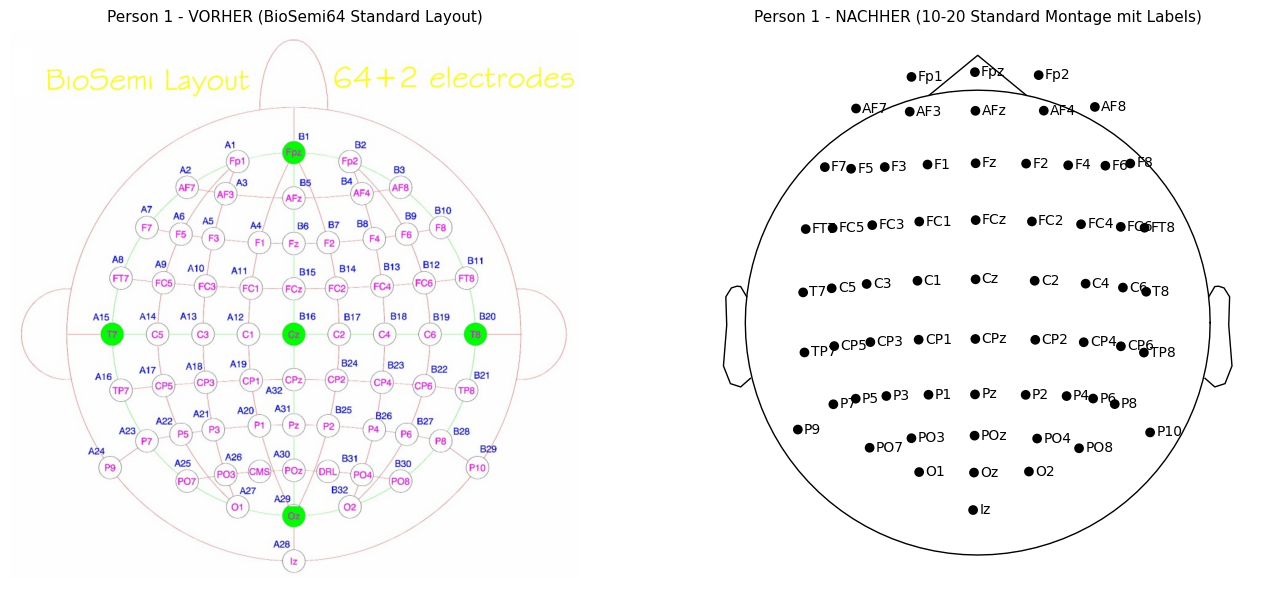

In [6]:
# Visualisiere die Elektrodenpositionen
from PIL import Image

fig = plt.figure(figsize=(14, 6))

# VORHER: BioSemi64 Layout - echtes Bild laden
ax1 = plt.subplot(1, 2, 1)

# Versuche verschiedene Pfade
possible_paths = [
    Path.cwd().parent / 'eeg_pipeline' / 'biosemiActive2_cap_64_layout_medium.jpg',
    Path.cwd() / 'biosemiActive2_cap_64_layout_medium.jpg',
    Path.cwd().parent / 'biosemiActive2_cap_64_layout_medium.jpg',
]

biosemi_img_loaded = False
for img_path in possible_paths:
    if img_path.exists():
        try:
            biosemi_img = Image.open(img_path)
            ax1.imshow(biosemi_img)
            ax1.axis('off')
            ax1.set_title('Person 1 - VORHER (BioSemi64 Standard Layout)', fontsize=11)
            biosemi_img_loaded = True
            print(f"BioSemi Layout Bild geladen von: {img_path}")
            break
        except Exception as e:
            print(f"Fehler beim Laden von {img_path}: {e}")

if not biosemi_img_loaded:
    # Falls Bild nicht gefunden, Alternative Darstellung
    ax1.text(0.5, 0.5, 'BioSemi64 Layout\n(Bild nicht gefunden)', 
             ha='center', va='center', fontsize=12, transform=ax1.transAxes)
    ax1.axis('off')
    ax1.set_title('Person 1 - VORHER (BioSemi64 Standard Layout)', fontsize=11)
    print("BioSemi Layout Bild konnte nicht gefunden werden")

# NACHHER: Mit 10-20 Montage und Kanalnamen
ax2 = plt.subplot(1, 2, 2)
eeg_p1_after.plot_sensors(show=False, axes=ax2, show_names=True)
ax2.set_title('Person 1 - NACHHER (10-20 Standard Montage mit Labels)', fontsize=11)

plt.tight_layout()
plt.show()


## 6. Datenqualität: Vergleich VORHER/NACHHER

In [ ]:
# Vergleiche Datenqualität (sollte gleich sein, nur Names/Montage geändert)
# Memory-efficient: Use only first 60 seconds for comparison
tmax_compare = min(60, raw_p1_before.times[-1])  # First 60 seconds or less
data_before_p1 = raw_p1_before.copy().pick('eeg').get_data(tmax=tmax_compare)
data_after_p1 = raw_p1_after.copy().pick('eeg').get_data(tmax=tmax_compare)

print(f"\n=== DATENQUALITÄT VERGLEICH (Person 1, erste {tmax_compare:.1f}s) ===\n")

# Die Daten sollten identisch sein
if np.array_equal(data_before_p1, data_after_p1):
    print("✓ Daten sind IDENTISCH (nur Kanal-Namen geändert)")
else:
    # Prüfe die Differenz
    diff = data_after_p1 - data_before_p1
    max_diff = np.max(np.abs(diff))
    print(f"⚠ Daten haben Unterschiede:")
    print(f"  Max Differenz: {max_diff}")
    if max_diff > 1e-10:  # Floating point errors sind ok
        print(f"  → Dies könnte ein Problem sein!")
    else:
        print(f"  → Nur numerische Rundungsfehler (OK)")

print(f"\nDatenstatistiken VORHER:")
print(f"  Shape: {data_before_p1.shape}")
print(f"  Min: {np.min(data_before_p1):.6f}")
print(f"  Max: {np.max(data_before_p1):.6f}")
print(f"  Mean: {np.mean(data_before_p1):.6f}")

print(f"\nDatenstatistiken NACHHER:")
print(f"  Shape: {data_after_p1.shape}")
print(f"  Min: {np.min(data_after_p1):.6f}")
print(f"  Max: {np.max(data_after_p1):.6f}")
print(f"  Mean: {np.mean(data_after_p1):.6f}")

MemoryError: Unable to allocate 3.58 GiB for an array with shape (64, 7514112) and data type float64

## 7. Zusammenfassung & Validierung

In [ ]:
print(f"\n=== SANITY CHECK ZUSAMMENFASSUNG ===\n")

checks = []

# 1. Kanal-Namen sollten geändert sein
ch_names_changed = eeg_p1_before.ch_names != eeg_p1_after.ch_names
checks.append(("Kanal-Namen geändert (P1)", ch_names_changed))

ch_names_changed_p2 = eeg_p2_before.ch_names != eeg_p2_after.ch_names
checks.append(("Kanal-Namen geändert (P2)", ch_names_changed_p2))

# 2. Montage sollte gesetzt sein
montage_set_p1 = raw_p1_after.get_montage() is not None
montage_set_p2 = raw_p2_after.get_montage() is not None
checks.append(("Montage gesetzt (P1)", montage_set_p1))
checks.append(("Montage gesetzt (P2)", montage_set_p2))

# 3. Gleiche Anzahl EEG Kanäle
same_n_channels = len(eeg_p1_before.ch_names) == len(eeg_p1_after.ch_names)
checks.append(("Gleiche Anzahl EEG Kanäle", same_n_channels))

# 4. Gleiche Datenlänge
same_n_samples = raw_p1_before.n_times == raw_p1_after.n_times
checks.append(("Gleiche Datenlänge", same_n_samples))

# 5. Daten sollten (nahezu) identisch sein - Speicher-effiziente Vergleich
# Statt alle Daten zu vergleichen, vergleiche ein Sample und die statistischen Properties
data_equal = True
try:
    # Vergleiche nur ein Sample von Daten (um Speicher zu sparen)
    sample_size = min(100000, data_before_p1.shape[1])  # Maximal 100k Samples
    sample_before = data_before_p1[:, :sample_size]
    sample_after = data_after_p1[:, :sample_size]
    
    if not np.allclose(sample_before, sample_after):
        data_equal = False
        print("⚠ Sample-Daten unterscheiden sich!")
except MemoryError:
    # Falls auch Sample zu groß ist, nur Shape vergleichen
    print("⚠ Speicher-Warnung: Vergleiche nur Datenform statt Werte")
    data_equal = (data_before_p1.shape == data_after_p1.shape)

checks.append(("Daten identisch (nur Metadaten geändert)", data_equal))

for check_name, result in checks:
    status = "✓ PASS" if result else "✗ FAIL"
    print(f"{status}: {check_name}")

all_pass = all(result for _, result in checks)
print(f"\n{'='*50}")
if all_pass:
    print("✓ ALLE CHECKS BESTANDEN")
else:
    print("✗ EINIGE CHECKS FEHLGESCHLAGEN")
print(f"{'='*50}")
